In [1]:
# Import Libraries
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

File not found at /content/Transformers.jpeg. Please upload 'dog.jpg'.


Saving Transformers.jpeg to Transformers.jpeg
No file named 'dog.jpg' was uploaded. Please upload the correct file or update the path.


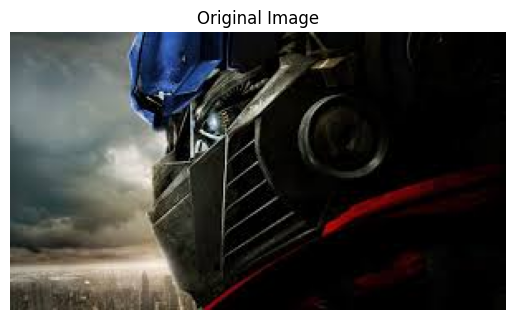

In [2]:
from google.colab import files
import os

# Check if the file exists, if not, prompt to upload
image_path = "/content/Transformers.jpeg"

if not os.path.exists(image_path):
    print(f"File not found at {image_path}. Please upload 'Transformers.jpeg'.")
    uploaded = files.upload()
    if "dog.jpg" in uploaded:
        print("File 'Transformers.jpeg' uploaded successfully.")
    else:
        print("No file named 'Transformers.jpeg' was uploaded. Please upload the correct file or update the path.")
        # You might want to exit or handle this case differently

# Load Image
img = Image.open(image_path)   # using the determined image_path

# Display using matplotlib
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


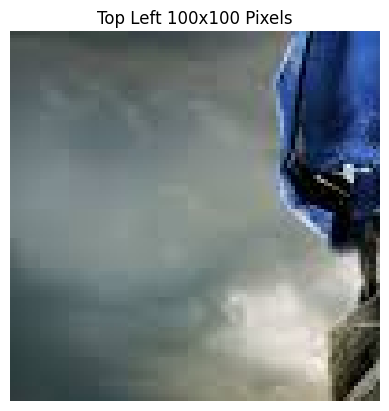

In [4]:
# Convert image to numpy array
img_array = np.array(img)

# Extract top-left 100x100 region
top_left = img_array[0:100, 0:100]

# Display
plt.imshow(top_left)
plt.title("Top Left 100x100 Pixels")
plt.axis("off")
plt.show()

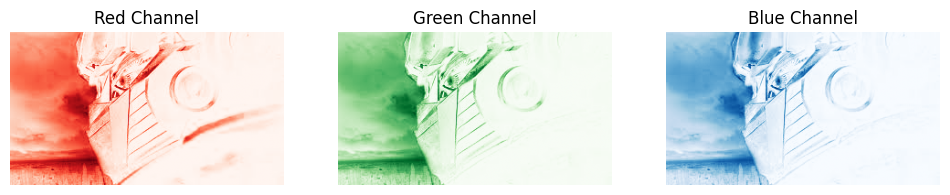

In [5]:
# Separate channels
R = img_array[:,:,0]
G = img_array[:,:,1]
B = img_array[:,:,2]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap="Reds")
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap="Greens")
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap="Blues")
plt.title("Blue Channel")
plt.axis("off")

plt.show()

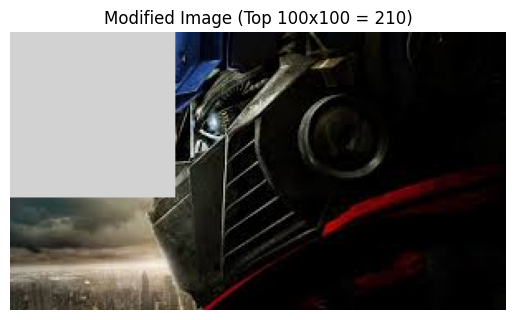

In [6]:
# Modify region
modified = img_array.copy()
modified[0:100,0:100] = 210

# Display result
plt.imshow(modified)
plt.title("Modified Image (Top 100x100 = 210)")
plt.axis("off")
plt.show()

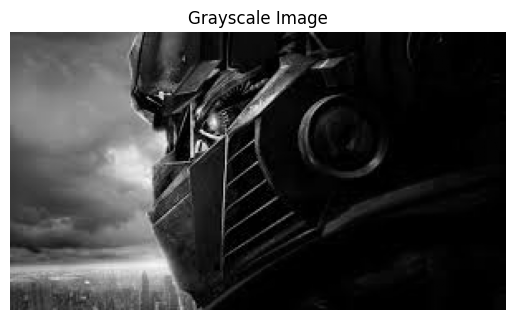

In [8]:
# Load grayscale image
gray_img = Image.open("/content/Transformers.jpeg").convert("L")

plt.imshow(gray_img, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

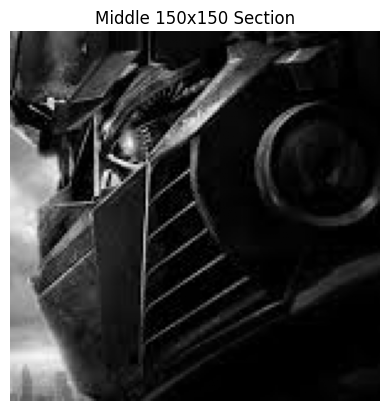

In [9]:
gray_array = np.array(gray_img)

h, w = gray_array.shape

center_h = h//2
center_w = w//2

middle = gray_array[center_h-75:center_h+75, center_w-75:center_w+75]

plt.imshow(middle, cmap="gray")
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

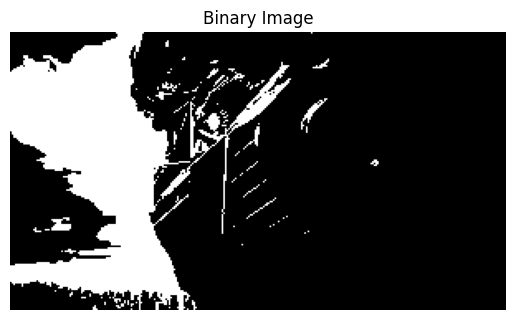

In [10]:
binary = gray_array.copy()

binary[binary < 100] = 0
binary[binary >= 100] = 255

plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")
plt.show()

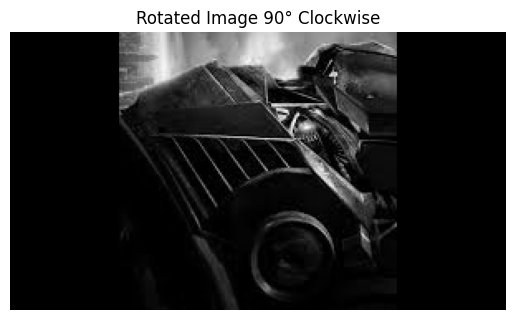

In [11]:
rotated = gray_img.rotate(-90)

plt.imshow(rotated, cmap="gray")
plt.title("Rotated Image 90° Clockwise")
plt.axis("off")
plt.show()

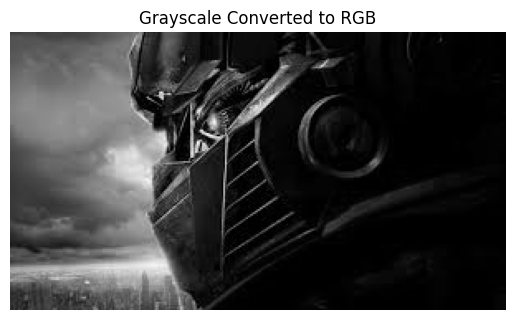

In [12]:
rgb_img = np.stack((gray_array,)*3, axis=-1)

plt.imshow(rgb_img)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

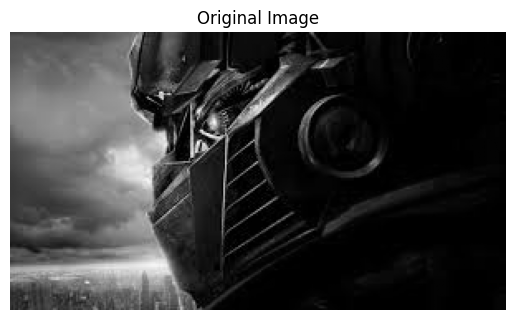

In [14]:
# Load image and convert to grayscale
img = Image.open("/content/Transformers.jpeg").convert("L")

img_array = np.array(img)

plt.imshow(img_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

# Standardize data
mean = np.mean(img_array, axis=0)
centered = img_array - mean

# Covariance matrix
cov_matrix = np.cov(centered, rowvar=False)

In [15]:
mean = np.mean(img_array, axis=0)
centered_data = img_array - mean

In [16]:
cov_matrix = np.cov(centered_data, rowvar=False)

In [17]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

In [18]:
sorted_index = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[sorted_index]
eigenvectors = eigenvectors[:, sorted_index]

In [19]:
explained_variance = eigenvalues / np.sum(eigenvalues)

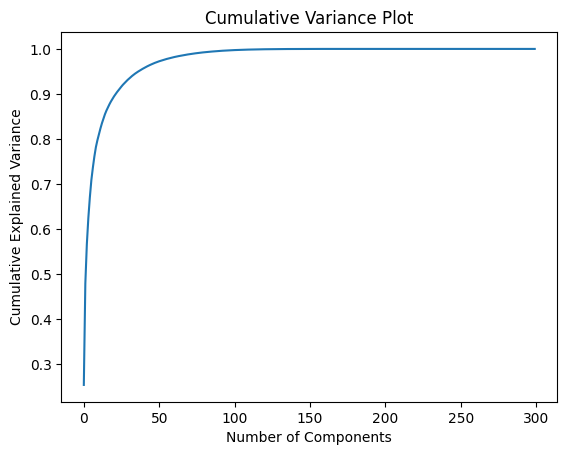

In [20]:
cumulative_variance = np.cumsum(explained_variance)

plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance Plot")
plt.show()

In [22]:
def reconstruct_image(k):
    eigenvector_subset = eigenvectors[:, :k]
    reduced_data = np.dot(centered_data, eigenvector_subset)
    reconstructed = np.dot(reduced_data, eigenvector_subset.T) + mean
    return reconstructed

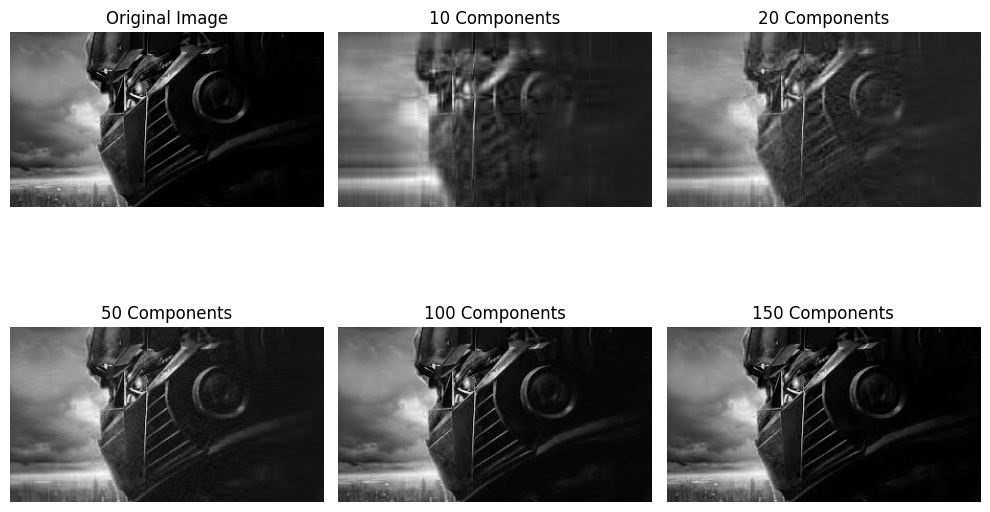

In [23]:
components = [10, 20, 50, 100, 150]

plt.figure(figsize=(10,7))

plt.subplot(2,3,1)
plt.imshow(img_array, cmap='gray')
plt.title("Original Image")
plt.axis("off")

for i, k in enumerate(components):

    reconstructed_img = reconstruct_image(k)

    plt.subplot(2,3,i+2)
    plt.imshow(reconstructed_img, cmap='gray')
    plt.title(f"{k} Components")
    plt.axis("off")

plt.tight_layout()
plt.show()